## **011963 ML for Civil and Environmental Engineering**

#### **03. Variable Types, Encoding & Feature Engineering**
#### **Made by SSJin (2026.03.16)**
#### Sejong University, Dept. of Civil & Environmental Engineering

---

> **Convention:**
> - <font color='blue'>**Blue = Example**</font>: Worked examples with complete code.
> - <font color='red'>**Red = Exercise**</font>: Fill in the blanks (`________`).
> - Answer keys are at the bottom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

---
#### **0 - 11 Types of Variables in a Dataset**

Before encoding, we must understand what types of variables exist in real-world datasets.

##### **0.1 Independent and Dependent Variables**

| Type | Description | Example |
|------|-------------|----------|
| **Independent** (Feature) | Input used to make predictions | Concrete mix ratio, curing days |
| **Dependent** (Target) | Output we want to predict | Compressive strength (MPa) |

In ML notation: Features = $X$, Target = $y$, Model: $y = f(X)$

##### **0.2 Confounding and Correlated Variables**

- **Correlated**: Two variables that move together (e.g., temperature and ice cream sales)
- **Confounding**: A hidden variable that influences both $X$ and $y$, creating a spurious relationship

> **Caution**: Correlation ≠ Causation. A confounding variable can make unrelated variables appear correlated.

##### **0.3 Other Important Variable Types**

| # | Type | Description | Example |
|---|------|-------------|----------|
| 5 | **Control** | Held constant to isolate effects | Lab temperature during concrete tests |
| 6 | **Latent** | Cannot be directly measured | Structural integrity |
| 7 | **Interaction** | Combined effect of two variables | Cement × Water ratio |
| 8-9 | **Stationary / Non-stationary** | Statistical properties change over time or not | River flow (seasonal = non-stationary) |
| 10 | **Lagged** | Past values used as features | Yesterday's temperature to predict today's |
| 11 | **Leaky** | Information from the future that leaks into training | Using test results available only after prediction |

---
#### **1 - Categorical Variable Encoding**

Machine learning models require **numerical** inputs. Categorical variables (e.g., material type, weather condition) must be converted to numbers. The encoding method matters!

##### **1.1 Sample Dataset**

<font color='blue'>**Example) Create a sample dataset with categorical variables**</font>

In [2]:
data = {
    'Temperature': ['Hot', 'Cold', 'Very Hot', 'Warm', 'Hot', 'Warm', 'Warm', 'Hot', 'Hot', 'Cold'],
    'Color': ['Red', 'Yellow', 'Blue', 'Blue', 'Red', 'Yellow', 'Red', 'Yellow', 'Yellow', 'Yellow'],
    'Target': [1, 1, 1, 0, 1, 0, 1, 0, 1, 1]
}
df0 = pd.DataFrame(data)
df0

,Temperature,Color,Target
0,Hot,Red,1
1,Cold,Yellow,1
2,Very Hot,Blue,1
3,Warm,Blue,0
4,Hot,Red,1
5,Warm,Yellow,0
6,Warm,Red,1
7,Hot,Yellow,0
8,Hot,Yellow,1
9,Cold,Yellow,1


##### **1.2 Why Can't We Feed Categories Directly?**

If we assign `Cold=1, Warm=2, Hot=3, Very Hot=4`, the model may incorrectly assume:
- `Very Hot` is 4× `Cold`
- `Hot` − `Warm` = `Warm` − `Cold`

These **ordinal assumptions** may not hold. Different encoding methods handle this differently.

##### **1.3 Method #1: One-Hot Encoding**

Creates a **binary column** for each category. Each row has exactly one `1`.

| Original | Cold | Hot | Very Hot | Warm |
|----------|------|-----|----------|------|
| Hot | 0 | 1 | 0 | 0 |
| Cold | 1 | 0 | 0 | 0 |

<font color='blue'>**Example) One-Hot Encoding using `pd.get_dummies()`**</font>

In [3]:
df = pd.get_dummies(df0, prefix=['Temp'], columns=['Temperature'], dtype=int)
df

,Color,Target,Temp_Cold,Temp_Hot,Temp_Very Hot,Temp_Warm
0,Red,1,0,1,0,0
1,Yellow,1,1,0,0,0
2,Blue,1,0,0,1,0
3,Blue,0,0,0,0,1
4,Red,1,0,1,0,0
5,Yellow,0,0,0,0,1
6,Red,1,0,0,0,1
7,Yellow,0,0,1,0,0
8,Yellow,1,0,1,0,0
9,Yellow,1,1,0,0,0


<font color='blue'>**Example) One-Hot Encoding using `sklearn.OneHotEncoder`**</font>

In [4]:
from sklearn.preprocessing import OneHotEncoder

ohc = OneHotEncoder(sparse_output=False)
ohe = ohc.fit_transform(df0[['Temperature']])
ohe_df = pd.DataFrame(ohe, columns=[f'Temp_{cat}' for cat in ohc.categories_[0]])

result = pd.concat([df0, ohe_df], axis=1)
result

,Temperature,Color,Target,Temp_Cold,Temp_Hot,Temp_Very Hot,Temp_Warm
0,Hot,Red,1,0.0,1.0,0.0,0.0
1,Cold,Yellow,1,1.0,0.0,0.0,0.0
2,Very Hot,Blue,1,0.0,0.0,1.0,0.0
3,Warm,Blue,0,0.0,0.0,0.0,1.0
4,Hot,Red,1,0.0,1.0,0.0,0.0
5,Warm,Yellow,0,0.0,0.0,0.0,1.0
6,Warm,Red,1,0.0,0.0,0.0,1.0
7,Hot,Yellow,0,0.0,1.0,0.0,0.0
8,Hot,Yellow,1,0.0,1.0,0.0,0.0
9,Cold,Yellow,1,1.0,0.0,0.0,0.0


> **⚠️ Caution (Dummy Variable Trap)**: Using all $k$ one-hot columns introduces **multicollinearity** (one column is perfectly predictable from the others). For linear models, use `drop_first=True` to drop one column.

##### **1.4 Method #2: Label Encoding**

Assigns a unique integer to each category. **No ordering** is implied.

| Category | Label |
|----------|-------|
| Hot | 0 |
| Cold | 1 |
| Very Hot | 2 |
| Warm | 3 |

<font color='blue'>**Example) Label Encoding using `sklearn.LabelEncoder`**</font>

In [5]:
from sklearn.preprocessing import LabelEncoder

df = df0.copy()
df['Temp_label'] = LabelEncoder().fit_transform(df['Temperature'])
df

,Temperature,Color,Target,Temp_label
0,Hot,Red,1,1
1,Cold,Yellow,1,0
2,Very Hot,Blue,1,2
3,Warm,Blue,0,3
4,Hot,Red,1,1
5,Warm,Yellow,0,3
6,Warm,Red,1,3
7,Hot,Yellow,0,1
8,Hot,Yellow,1,1
9,Cold,Yellow,1,0


##### **1.5 Method #3: Ordinal Encoding**

When categories have a **natural order** (e.g., Cold < Warm < Hot < Very Hot), we assign integers that respect this order.

<font color='blue'>**Example) Ordinal Encoding using a mapping dictionary**</font>

In [6]:
temp_order = {'Cold': 1, 'Warm': 2, 'Hot': 3, 'Very Hot': 4}

df = df0.copy()
df['Temp_ordinal'] = df['Temperature'].map(temp_order)
df

,Temperature,Color,Target,Temp_ordinal
0,Hot,Red,1,3
1,Cold,Yellow,1,1
2,Very Hot,Blue,1,4
3,Warm,Blue,0,2
4,Hot,Red,1,3
5,Warm,Yellow,0,2
6,Warm,Red,1,2
7,Hot,Yellow,0,3
8,Hot,Yellow,1,3
9,Cold,Yellow,1,1


##### **1.6 Method #4: Binary Encoding**

Converts category labels to binary code. Uses fewer columns than one-hot for high-cardinality features.

| Category | Binary | Col_1 | Col_2 |
|----------|--------|-------|-------|
| Cold (1) | 01 | 0 | 1 |
| Warm (2) | 10 | 1 | 0 |
| Hot (3) | 11 | 1 | 1 |

<font color='blue'>**Example) Binary Encoding using `category_encoders`**</font>

In [7]:
import category_encoders as ce

df = df0.copy()
encoder = ce.BinaryEncoder(cols=['Temperature'])
df_bin = encoder.fit_transform(df['Temperature'])
result = pd.concat([df, df_bin], axis=1)
result

,Temperature,Color,Target,Temperature_0,Temperature_1,Temperature_2
0,Hot,Red,1,0,0,1
1,Cold,Yellow,1,0,1,0
2,Very Hot,Blue,1,0,1,1
3,Warm,Blue,0,1,0,0
4,Hot,Red,1,0,0,1
5,Warm,Yellow,0,1,0,0
6,Warm,Red,1,1,0,0
7,Hot,Yellow,0,0,0,1
8,Hot,Yellow,1,0,0,1
9,Cold,Yellow,1,0,1,0


##### **1.7 Summary: When to Use Which?**

| Method | # Columns | Preserves Order? | Best For |
|--------|-----------|-----------------|----------|
| One-Hot | $k$ (or $k$−1) | No | Nominal categories, <10 categories |
| Label | 1 | No | Tree-based models only |
| Ordinal | 1 | Yes | Naturally ordered categories |
| Binary | $\lceil\log_2 k\rceil$ | No | High cardinality (many categories) |

<font color='red'>**Exercise 1.1) Encode the `Color` column using One-Hot Encoding with `pd.get_dummies()` (with `drop_first=True`)**</font>

In [10]:
df = df0.copy()
df_encoded = pd.get_dummies(df, prefix=['Color'], columns=['Color'], 
                           drop_first=True, dtype=int)
                           # prefix: 새로 생기는 컬럼 이름 앞에 'Color'라는 접두어를 붙이는 파라미터
df_encoded

,Temperature,Target,Color_Red,Color_Yellow
0,Hot,1,1,0
1,Cold,1,0,1
2,Very Hot,1,0,0
3,Warm,0,0,0
4,Hot,1,1,0
5,Warm,0,0,1
6,Warm,1,1,0
7,Hot,0,0,1
8,Hot,1,0,1
9,Cold,1,0,1


<font color='red'>**Exercise 1.2) Create an ordinal encoding for a `Concrete_Grade` column.**</font>

The grades have a natural order: `Low < Normal < High < Ultra-High`

In [9]:
grade_data = pd.DataFrame({
    'Concrete_Grade': ['Normal', 'High', 'Low', 'Ultra-High', 'Normal', 'High', 'Low', 'Normal'],
    'Strength_MPa': [30, 50, 15, 80, 28, 55, 12, 32]
})

# Create ordinal mapping
grade_order = {
    'Low': 0,
    'Normal': 1,
    'High': 2,
    'Ultra-High': 3
}

grade_data['Grade_encoded'] = grade_data['Concrete_Grade'].map(grade_order)
grade_data

,Concrete_Grade,Strength_MPa,Grade_encoded
0,Normal,30,1
1,High,50,2
2,Low,15,0
3,Ultra-High,80,3
4,Normal,28,1
5,High,55,2
6,Low,12,0
7,Normal,32,1


<font color='red'>**Exercise 1.3) Use `LabelEncoder` to encode the `Color` column. Print the mapping.**</font>

In [ ]:
df = df0.copy()
le = LabelEncoder()
df['Color_label'] = le.fit_transform(df['Color'])

# Print the mapping
print('Mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
# classes_: fit() 후 자동으로 저장되는 속성으로 학습한 카테고리 목록을 알파벳 순으로 저장, ['Blue', 'Green', 'Red']
df

Mapping: {'Blue': 0, 'Red': 1, 'Yellow': 2}


,Temperature,Color,Target,Color_label
0,Hot,Red,1,1
1,Cold,Yellow,1,2
2,Very Hot,Blue,1,0
3,Warm,Blue,0,0
4,Hot,Red,1,1
5,Warm,Yellow,0,2
6,Warm,Red,1,1
7,Hot,Yellow,0,2
8,Hot,Yellow,1,2
9,Cold,Yellow,1,2


---
#### **2 - Cyclical Variable Encoding**

##### **2.1 What Are Cyclical Features?**

Some features are **cyclical** — they wrap around:
- Hours: 23 → 0 (midnight)
- Months: December → January
- Wind direction: 359° → 0°
- Day of week: Sunday → Monday

**Problem**: If we encode months as 1–12, the model thinks December (12) and January (1) are far apart, when they're actually adjacent!

##### **2.2 Sine/Cosine Encoding**

The solution is to map the cyclical feature onto a **circle** using sine and cosine:

$$x_{\sin} = \sin\left(\frac{2\pi \cdot x}{\text{period}}\right), \quad x_{\cos} = \cos\left(\frac{2\pi \cdot x}{\text{period}}\right)$$

This preserves the circular distance between values.

<font color='blue'>**Example) Visualize why sine/cosine encoding works for months**</font>

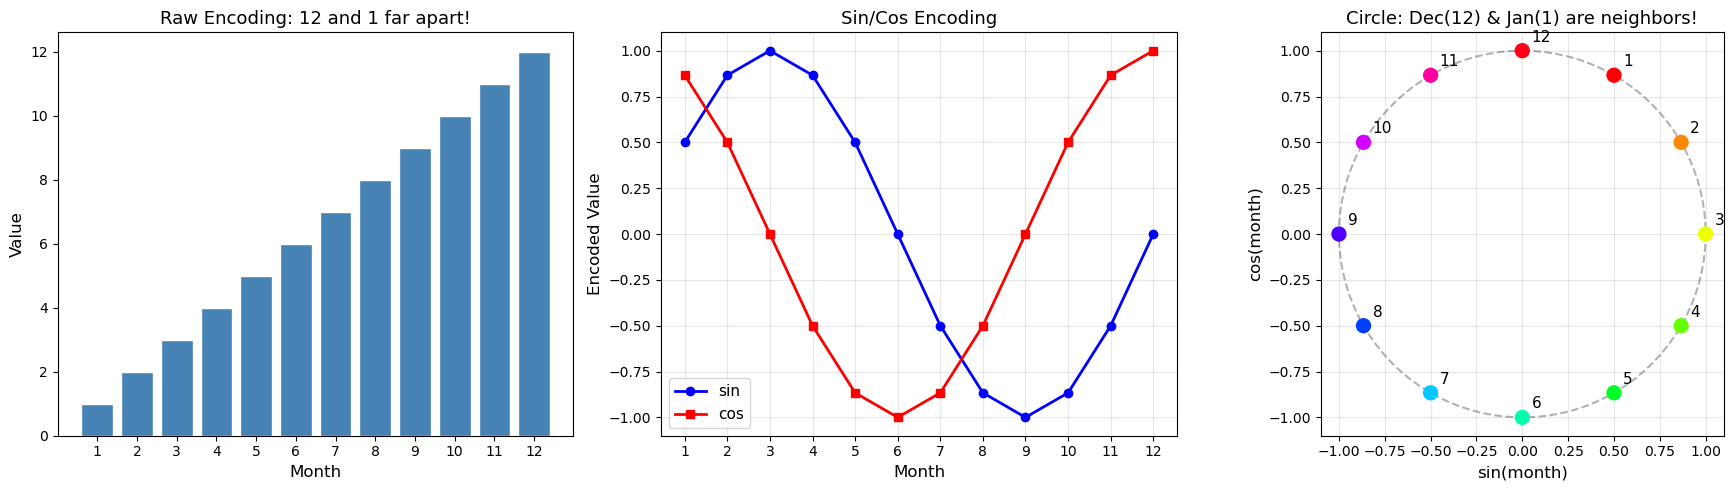

In [12]:
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Raw month numbers (problem: 12 and 1 far apart)
axes[0].bar(months, months, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Month', fontsize=12); axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Raw Encoding: 12 and 1 far apart!', fontsize=13)
axes[0].set_xticks(months)

# Middle: Sin and Cos curves
axes[1].plot(months, month_sin, 'bo-', lw=2, label='sin')
axes[1].plot(months, month_cos, 'rs-', lw=2, label='cos')
axes[1].set_xlabel('Month', fontsize=12); axes[1].set_ylabel('Encoded Value', fontsize=12)
axes[1].set_title('Sin/Cos Encoding', fontsize=13)
axes[1].legend(fontsize=11); axes[1].set_xticks(months); axes[1].grid(True, alpha=0.3)

# Right: 2D circle (sin vs cos)
axes[2].scatter(month_sin, month_cos, s=100, c=months, cmap='hsv', zorder=5)
for i, m in enumerate(months):
    axes[2].annotate(f'{m}', (month_sin[i]+0.05, month_cos[i]+0.05), fontsize=11)
theta = np.linspace(0, 2*np.pi, 100)
axes[2].plot(np.sin(theta), np.cos(theta), 'k--', alpha=0.3)
axes[2].set_xlabel('sin(month)', fontsize=12); axes[2].set_ylabel('cos(month)', fontsize=12)
axes[2].set_title('Circle: Dec(12) & Jan(1) are neighbors!', fontsize=13)
axes[2].set_aspect('equal'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

<font color='red'>**Exercise 2.1) Apply sine/cosine encoding to hours of the day (0–23).**</font>

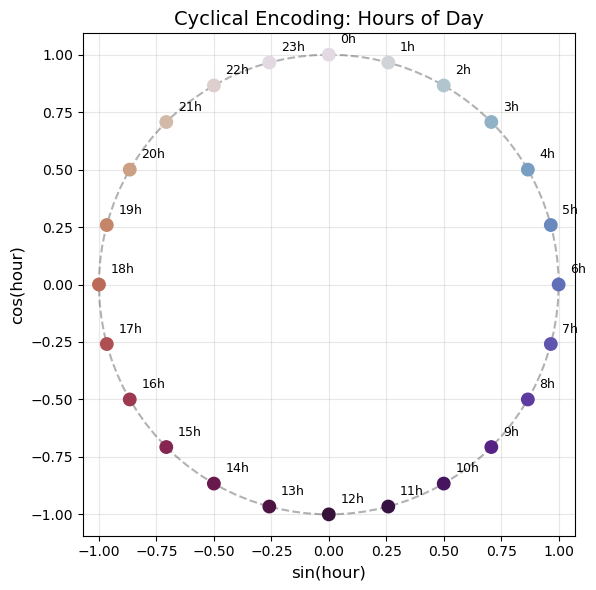

In [13]:
hours = np.arange(0, 24)
period = 24

hour_sin = np.sin(2 * np.pi * hours / period)
hour_cos = np.cos(2 * np.pi * hours / period)

# Plot the circle
plt.figure(figsize=(6, 6))
plt.scatter(hour_sin, hour_cos, s=80, c=hours, cmap='twilight', zorder=5)
for h in hours:
    plt.annotate(f'{h}h', (hour_sin[h]+0.05, hour_cos[h]+0.05), fontsize=9)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(theta), np.cos(theta), 'k--', alpha=0.3)
plt.xlabel('sin(hour)', fontsize=12); plt.ylabel('cos(hour)', fontsize=12)
plt.title('Cyclical Encoding: Hours of Day', fontsize=14)
plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
#### **3 - Time-Series Feature Engineering: Three Approaches**

We compare three methods for encoding time in a regression model:
1. **Dummy variables** (one-hot for each month)
2. **Sine/cosine** transformation
3. **Radial Basis Functions** (RBF)

##### **3.1 Setup and Synthetic Data**

<font color='blue'>**Example) Generate synthetic seasonal time-series data**</font>

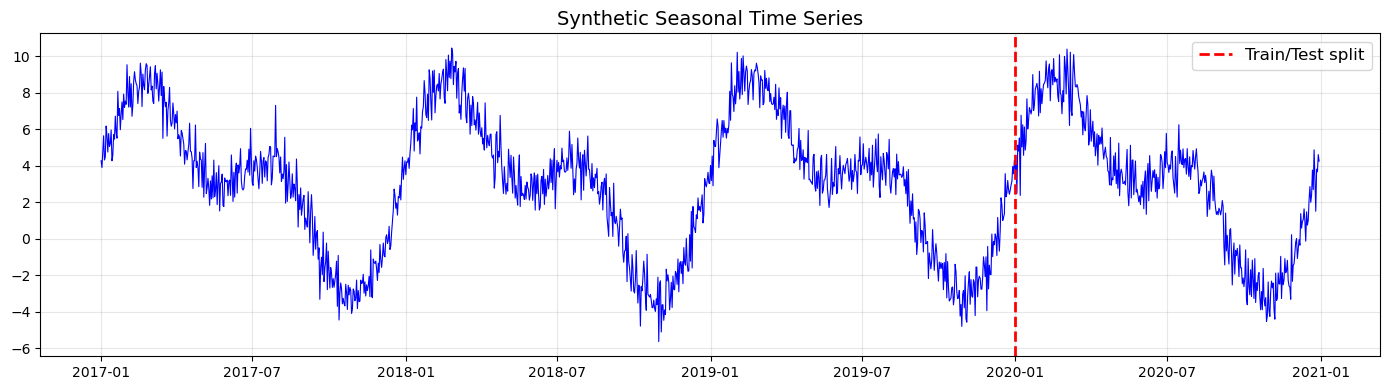

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_absolute_error

np.random.seed(42)

# Generate 4 years of daily data
dates = pd.date_range('2017-01-01', '2020-12-30')
X = pd.DataFrame(index=dates)
X['day_nr'] = range(len(X))
X['day_of_year'] = X.index.dayofyear

# Synthetic signal: trend + seasonal + noise, 합성된 신호라는 뜻으로 인공적인 시계열 데이터를 말함.
signal_1 = 3 + 4 * np.sin(X['day_nr'] / 365 * 2 * np.pi)
signal_2 = 3 * np.sin(X['day_nr'] / 365 * 4 * np.pi + 365/2)
noise = np.random.normal(0, 0.85, len(X))
y = signal_1 + signal_2 + noise

results_df = y.to_frame(name='actuals')
TRAIN_END = 3 * 365  # first 3 years = train

plt.figure(figsize=(14, 4))
plt.plot(dates, y, 'b-', linewidth=0.8)
plt.axvline(dates[TRAIN_END], color='red', ls='--', lw=2, label='Train/Test split')
plt.title('Synthetic Seasonal Time Series', fontsize=14)
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **3.2 Approach #1: Dummy Variables (One-Hot for Months)**

<font color='blue'>**Example) Fit a linear model using month dummy variables**</font>

            month_2  month_3  month_4  month_5  month_6  month_7  month_8  \
2017-01-01    False    False    False    False    False    False    False   
2017-01-02    False    False    False    False    False    False    False   
2017-01-03    False    False    False    False    False    False    False   
2017-01-04    False    False    False    False    False    False    False   
2017-01-05    False    False    False    False    False    False    False   

            month_9  month_10  month_11  month_12  
2017-01-01    False     False     False     False  
2017-01-02    False     False     False     False  
2017-01-03    False     False     False     False  
2017-01-04    False     False     False     False  
2017-01-05    False     False     False     False  


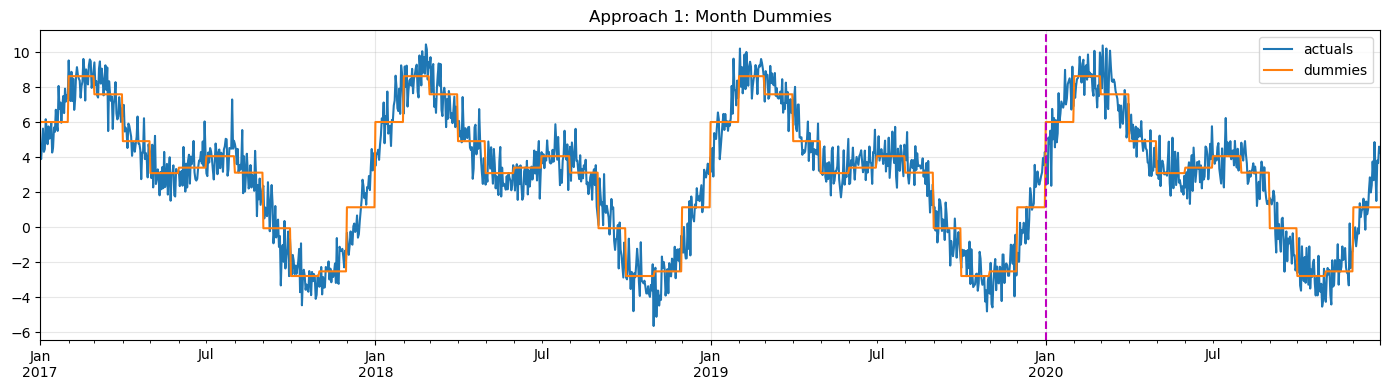

In [19]:
X_1 = pd.DataFrame(
    data=pd.get_dummies(X.index.month, drop_first=True, prefix='month')
)
X_1.index = X.index
print(X_1.head())

model_1 = LinearRegression().fit(X_1.iloc[:TRAIN_END], y.iloc[:TRAIN_END])
results_df['dummies'] = model_1.predict(X_1)

results_df[['actuals', 'dummies']].plot(figsize=(14, 4), title='Approach 1: Month Dummies')
plt.axvline(dates[TRAIN_END], c='m', ls='--'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **3.3 Approach #2: Sine/Cosine Transformation**

<font color='blue'>**Example) Fit using sine/cosine features of day-of-year**</font>

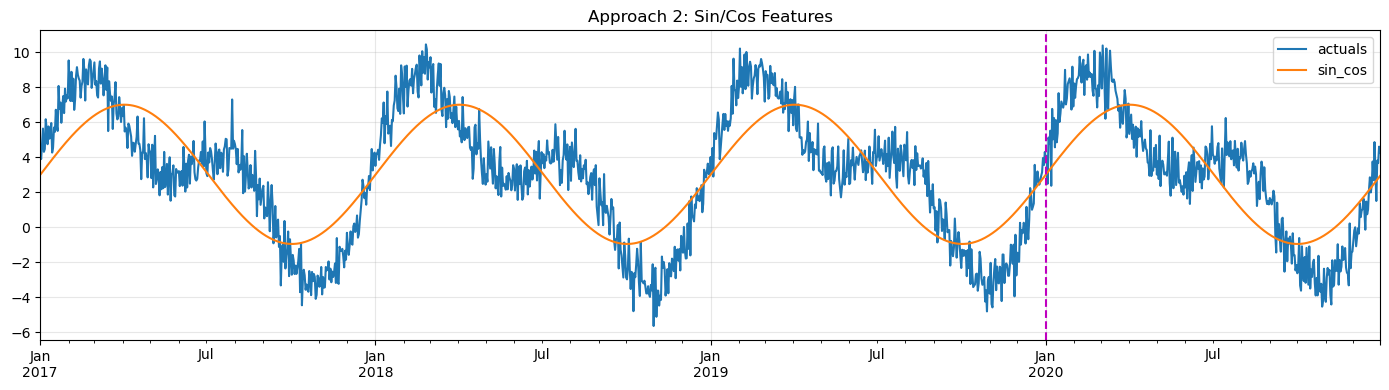

In [20]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

X_2 = X[['day_of_year']].copy()
X_2['day_sin'] = sin_transformer(365).fit_transform(X_2)['day_of_year']
X_2['day_cos'] = cos_transformer(365).fit_transform(X_2)['day_of_year']

model_2 = LinearRegression().fit(X_2[['day_sin','day_cos']].iloc[:TRAIN_END], y.iloc[:TRAIN_END])
results_df['sin_cos'] = model_2.predict(X_2[['day_sin','day_cos']])

results_df[['actuals', 'sin_cos']].plot(figsize=(14, 4), title='Approach 2: Sin/Cos Features')
plt.axvline(dates[TRAIN_END], c='m', ls='--'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##### **3.4 Approach #3: Radial Basis Functions (RBF)**

<font color='blue'>**Example) Fit using RBF features (requires `scikit-lego`)**</font>

In [22]:
%pip install scikit-lego


   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ---------------------------------------- 0/3 [narwhals]
   ------------- -------------------------- 1/3 [sklearn-compat]
   -------------------------- ------------- 2/3 [scikit-lego]
   -------------------------- ------------- 2/3 [scikit-lego]
   -------------------------- ------------- 2/3 [scikit-lego]
   ---------------------------------------- 3/3 [scikit-lego]

Note: you may need to restart the kernel to use updated packages.


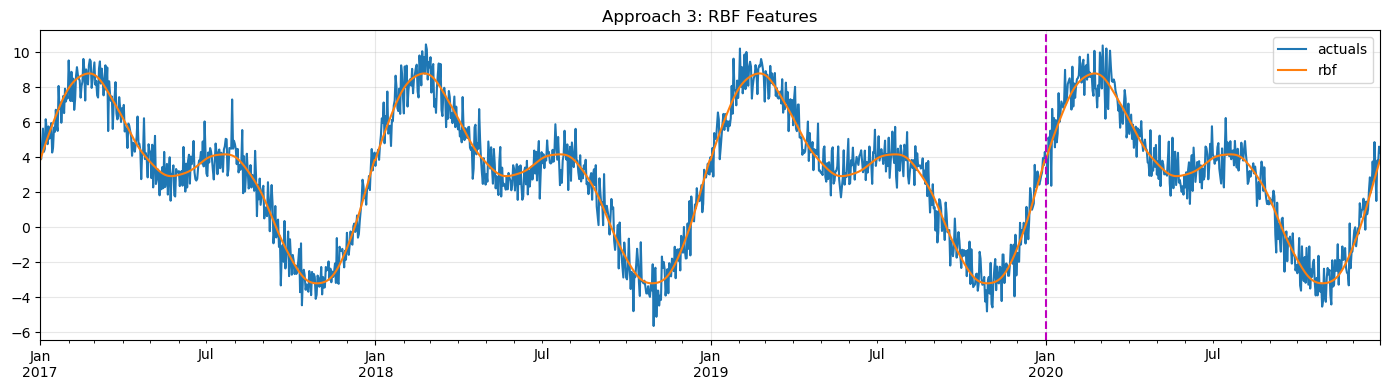

In [23]:
try:
    from sklego.preprocessing import RepeatingBasisFunction
    
    rbf = RepeatingBasisFunction(n_periods=12, column='day_of_year',
                                input_range=(1, 365), remainder='drop')
    rbf.fit(X)
    X_3 = pd.DataFrame(index=X.index, data=rbf.transform(X))
    
    model_3 = LinearRegression().fit(X_3.iloc[:TRAIN_END], y.iloc[:TRAIN_END])
    results_df['rbf'] = model_3.predict(X_3)
    
    results_df[['actuals', 'rbf']].plot(figsize=(14, 4), title='Approach 3: RBF Features')
    plt.axvline(dates[TRAIN_END], c='m', ls='--'); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
except ImportError:
    print('scikit-lego not installed. Run: pip install scikit-lego')
    print('Skipping RBF approach.')

##### **3.5 Final Comparison**

<font color='blue'>**Example) Compare all approaches side by side**</font>

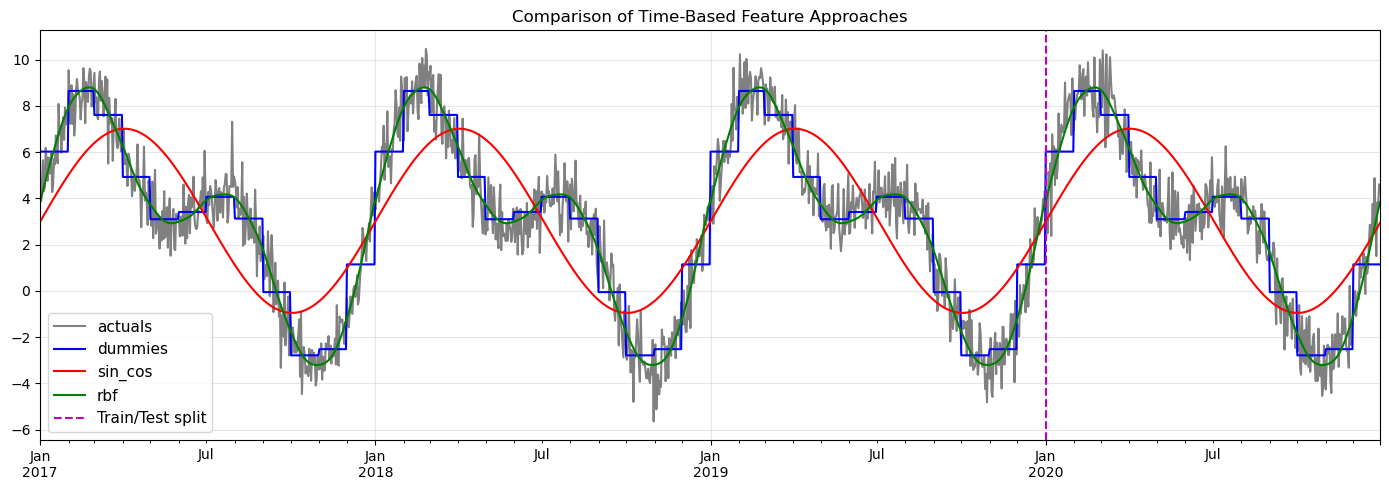

Model         Train MAE   Test MAE
----------------------------------
dummies          0.8765     0.9258
sin_cos          1.9766     1.9902
rbf              0.6577     0.6921


In [24]:
cols_to_plot = [c for c in results_df.columns if c != 'actuals']
plot_cols = ['actuals'] + cols_to_plot

results_df[plot_cols].plot(figsize=(14, 5),
    title='Comparison of Time-Based Feature Approaches',
    color=['gray','blue','red','green'][:len(plot_cols)])
plt.axvline(dates[TRAIN_END], c='m', ls='--', label='Train/Test split')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# MAE scores
print(f'{"Model":<12} {"Train MAE":>10} {"Test MAE":>10}')
print('-' * 34)
for col in cols_to_plot:
    train_mae = mean_absolute_error(results_df['actuals'].iloc[:TRAIN_END], results_df[col].iloc[:TRAIN_END])
    test_mae = mean_absolute_error(results_df['actuals'].iloc[TRAIN_END:], results_df[col].iloc[TRAIN_END:])
    print(f'{col:<12} {train_mae:>10.4f} {test_mae:>10.4f}')

<font color='red'>**Exercise 3.1) Create sine/cosine features for the `month` (period=12) and fit a linear model. Compare with the day-of-year model.**</font>

In [25]:
X_month = X[['day_of_year']].copy()
X_month['month'] = X.index.month

# Create sin/cos features for month (period = 12)
X_month['month_sin'] = np.sin(2 * np.pi * X_month['month'] / 12)
X_month['month_cos'] = np.cos(2 * np.pi * X_month['month'] / 12)

# Fit model using month sin/cos only
features = ['month_sin', 'month_cos']
model_month = LinearRegression().fit(X_month[features].iloc[:TRAIN_END], y.iloc[:TRAIN_END])
results_df['month_sincos'] = model_month.predict(X_month[features])

# Compare
train_mae = mean_absolute_error(results_df['actuals'].iloc[:TRAIN_END], results_df['month_sincos'].iloc[:TRAIN_END])
test_mae = mean_absolute_error(results_df['actuals'].iloc[TRAIN_END:], results_df['month_sincos'].iloc[TRAIN_END:])
print(f'Month sin/cos → Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}')

Month sin/cos → Train MAE: 1.9993, Test MAE: 2.0096


<font color='red'>**Exercise 3.2) For CEE context: encode wind direction (0–360°) as sine/cosine features and demonstrate that 350° and 10° are close in encoded space.**</font>

Raw distance between 350° and 10°: 340°
Encoded distance: 0.3473

The encoded distance is small, showing they are neighbors on the circle!


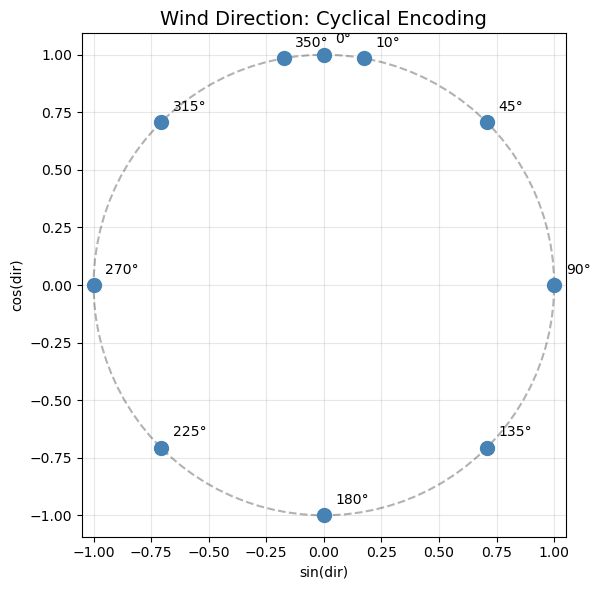

In [26]:
# Wind direction data (degrees)
wind_dirs = np.array([0, 45, 90, 135, 180, 225, 270, 315, 350, 10])
period = 360

wind_sin = np.sin(2 * np.pi * wind_dirs / period)
wind_cos = np.cos(2 * np.pi * wind_dirs / period)

# Compute Euclidean distance in encoded space between 350° and 10°
idx_350 = np.where(wind_dirs == 350)[0][0]
idx_10 = np.where(wind_dirs == 10)[0][0]
dist_encoded = np.sqrt((wind_sin[idx_350]-wind_sin[idx_10])**2 + (wind_cos[idx_350]-wind_cos[idx_10])**2)
dist_raw = abs(350 - 10)  # raw distance

print(f'Raw distance between 350° and 10°: {dist_raw}°')
print(f'Encoded distance: {dist_encoded:.4f}')
print(f'\nThe encoded distance is small, showing they are neighbors on the circle!')

# Visualize
plt.figure(figsize=(6, 6))
plt.scatter(wind_sin, wind_cos, s=100, c='steelblue', zorder=5)
for i, d in enumerate(wind_dirs):
    plt.annotate(f'{d}°', (wind_sin[i]+0.05, wind_cos[i]+0.05), fontsize=10)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(theta), np.cos(theta), 'k--', alpha=0.3)
plt.xlabel('sin(dir)'); plt.ylabel('cos(dir)')
plt.title('Wind Direction: Cyclical Encoding', fontsize=14)
plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
##### **Reference**
- [11 Types of Variables in a Dataset](https://blog.dailydoseofds.com/)
- [All about Categorical Variable Encoding](https://medium.com/towards-data-science/)
- [7 Categorical Data Encoding Techniques](https://blog.dailydoseofds.com/)
- [Cyclical Feature Engineering](https://blog.dailydoseofds.com/)
- [Three Approaches to Feature Engineering for Time Series](https://medium.com/towards-data-science/)
- [A Point of Caution When Using One-Hot Encoding](https://blog.dailydoseofds.com/)

---
**📌 Submission**: Complete all exercises → `Restart Kernel and Run All` → Save (`Ctrl+S`) → Submit via e-campus.